# Statistical Customer Segmentation System

## Notebook 02: Exploratory Data Analysis

### Purpose

This notebook explores customer purchasing behavior, transaction patterns, spending distributions, and geographic activity.

### Objectives

- Analyze customer activity
- Explore transaction behavior
- Investigate spending patterns
- Examine country-level sales activity
- Identify potential segmentation opportunities

### Expected Outcome

A comprehensive understanding of customer purchasing behavior that will inform feature engineering and clustering analyses.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import os

os.makedirs("images", exist_ok=True)

In [ ]:
df = pd.read_csv(
    "/content/cleaned_online_retail.csv"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Dataset Overview

Before investigating customer behavior, we examine the overall structure of the transaction dataset.

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nUnique Customers:")
print(df["CustomerID"].nunique())

print("\nUnique Countries:")
print(df["Country"].nunique())

print("\nUnique Products:")
print(df["StockCode"].nunique())

Rows: 54756
Columns: 9

Unique Customers:
1104

Unique Countries:
24

Unique Products:
2913


## Country-Level Transaction Analysis

Understanding geographic transaction activity helps reveal where most customer behavior originates.

In [ ]:
country_counts = (
    df["Country"]
    .value_counts()
    .head(10)
)

country_counts

,count
Country,
United Kingdom,51336
Germany,853
France,751
EIRE,432
Spain,302
Portugal,176
Norway,147
Belgium,130
Australia,102


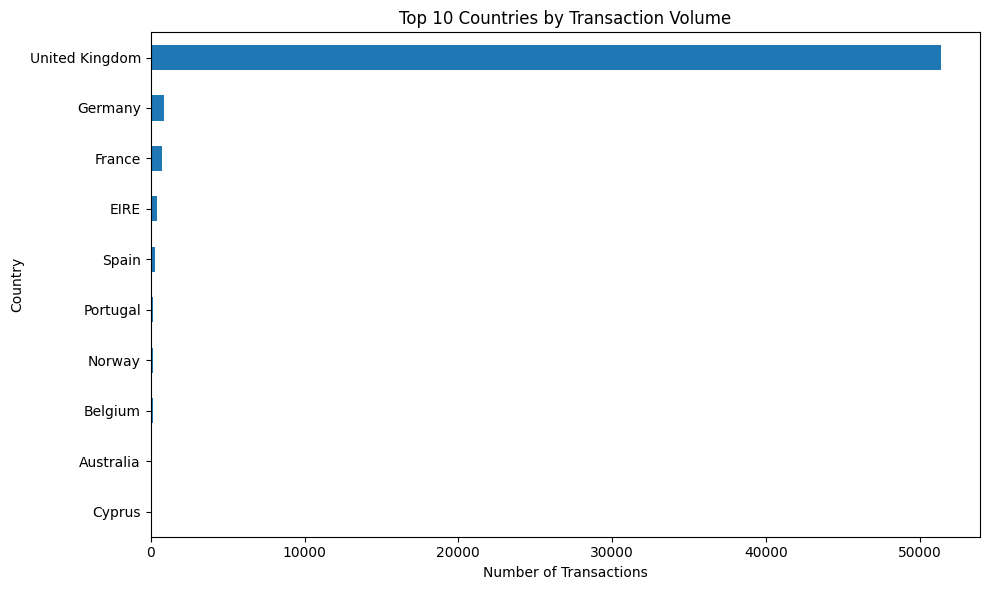

In [ ]:
plt.figure(figsize=(10,6))

country_counts.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Countries by Transaction Volume"
)

plt.xlabel(
    "Number of Transactions"
)

plt.tight_layout()

plt.savefig(
    "images/country_transactions.png",
    dpi=300
)

plt.show()

## Customer Activity Analysis

Customer activity levels vary substantially across retail datasets.

Identifying highly active customers provides insight into purchasing concentration.

In [ ]:
top_customers = (
    df["CustomerID"]
    .value_counts()
    .head(10)
)

top_customers

,count
CustomerID,
15287.0,20502
12748.0,668
17841.0,425
14606.0,357
14911.0,346
15311.0,320
17850.0,297
13081.0,260
15039.0,201


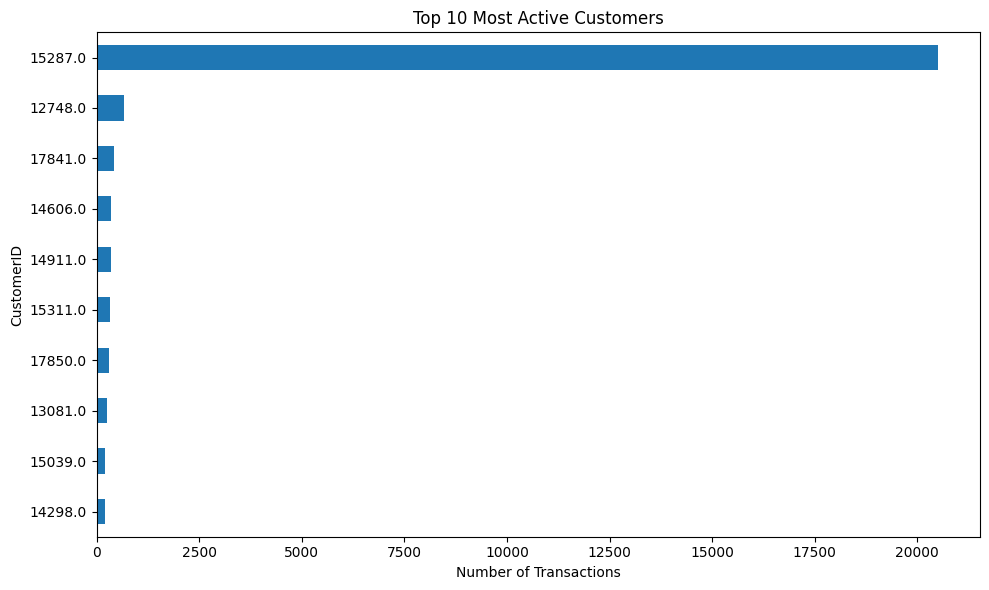

In [ ]:
plt.figure(figsize=(10,6))

top_customers.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Most Active Customers"
)

plt.xlabel(
    "Number of Transactions"
)

plt.tight_layout()

plt.savefig(
    "images/top_customers.png",
    dpi=300
)

plt.show()

## Sales Distribution Analysis

Customer transaction values are often highly skewed.

We examine both raw and log-transformed distributions.

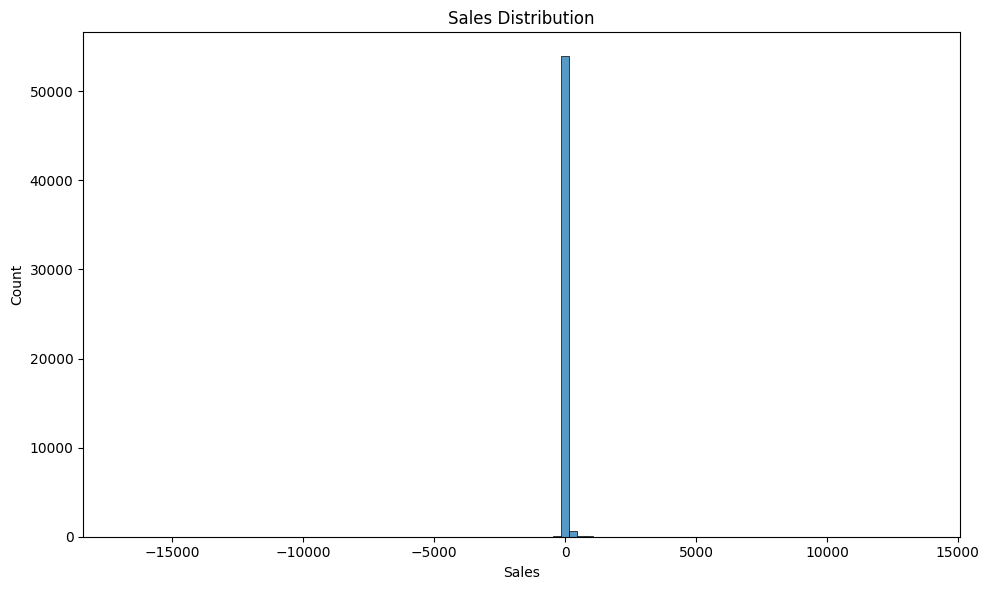

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Sales"],
    bins=100
)

plt.title(
    "Sales Distribution"
)

plt.tight_layout()

plt.show()

In [ ]:
positive_sales = (
    df[df["Sales"] > 0]["Sales"]
)

positive_sales.describe()

,Sales
count,53438.000000
mean,20.053363
std,103.660588
min,0.140000
25%,3.750000
50%,8.470000
75%,17.000000
max,13541.330000


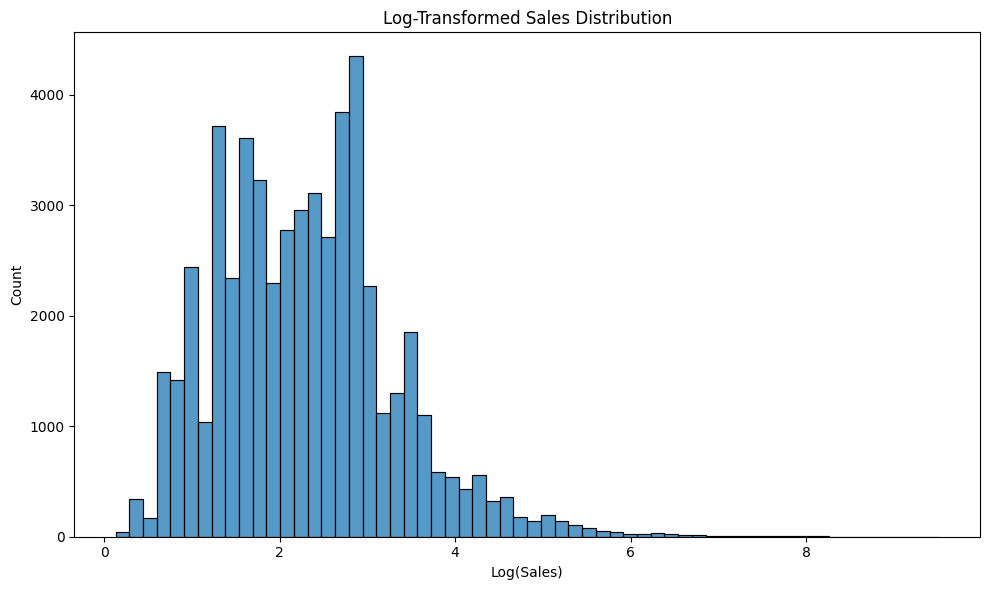

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(positive_sales),
    bins=60
)

plt.title(
    "Log-Transformed Sales Distribution"
)

plt.xlabel(
    "Log(Sales)"
)

plt.tight_layout()

plt.savefig(
    "images/sales_distribution_logscale.png",
    dpi=300
)

plt.show()

## Customer Spending Analysis

Customer segmentation relies heavily on spending behavior.

We investigate customer-level spending patterns.

In [ ]:
customer_spending = (
    df.groupby("CustomerID")["Sales"]
      .sum()
      .sort_values(
          ascending=False
      )
)

customer_spending.head()

,Sales
CustomerID,
15287.0,204223.96
18102.0,27834.61
15749.0,22998.40
15061.0,21264.71
17450.0,20649.04


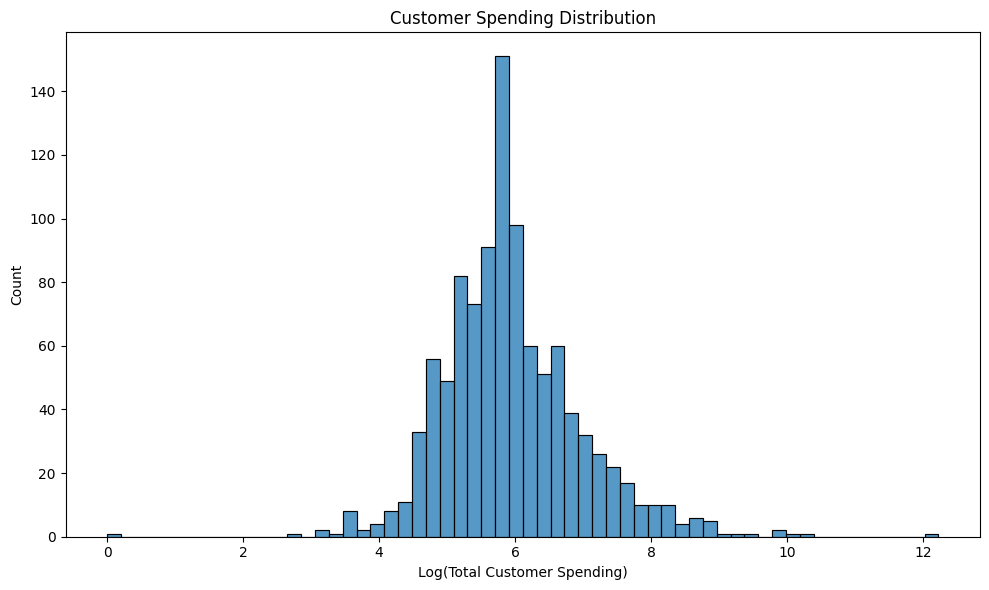

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(customer_spending),
    bins=60
)

plt.title(
    "Customer Spending Distribution"
)

plt.xlabel(
    "Log(Total Customer Spending)"
)

plt.tight_layout()

plt.savefig(
    "images/customer_spending_distribution.png",
    dpi=300
)

plt.show()

## Correlation Analysis

We investigate relationships among numerical variables that may influence future segmentation models.

In [ ]:
numeric_df = df[
    [
        "Quantity",
        "UnitPrice",
        "Sales"
    ]
]

corr_matrix = (
    numeric_df.corr()
)

corr_matrix

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.003738,0.232354
UnitPrice,-0.003738,1.000000,-0.626333
Sales,0.232354,-0.626333,1.000000


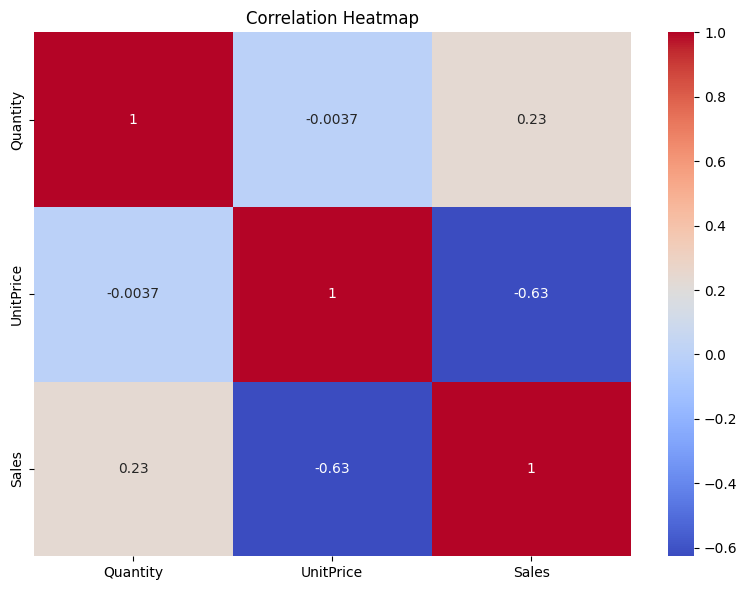

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300
)

plt.show()

## Exploratory Findings

### Key Insights

- Customer activity is concentrated among a relatively small number of customers.
- Transaction values exhibit strong positive skewness.
- Spending behavior demonstrates substantial heterogeneity.
- Geographic activity is concentrated within a small number of countries.
- Correlation analysis provides initial evidence of relationships among purchasing variables.

These findings support the use of dimensionality reduction and clustering techniques in subsequent analyses.

In [ ]:
customer_spending.describe()

,Sales
count,1104.000000
mean,865.032228
std,6361.916853
min,-1192.200000
25%,173.297500
50%,318.620000
75%,606.340000
max,204223.960000
